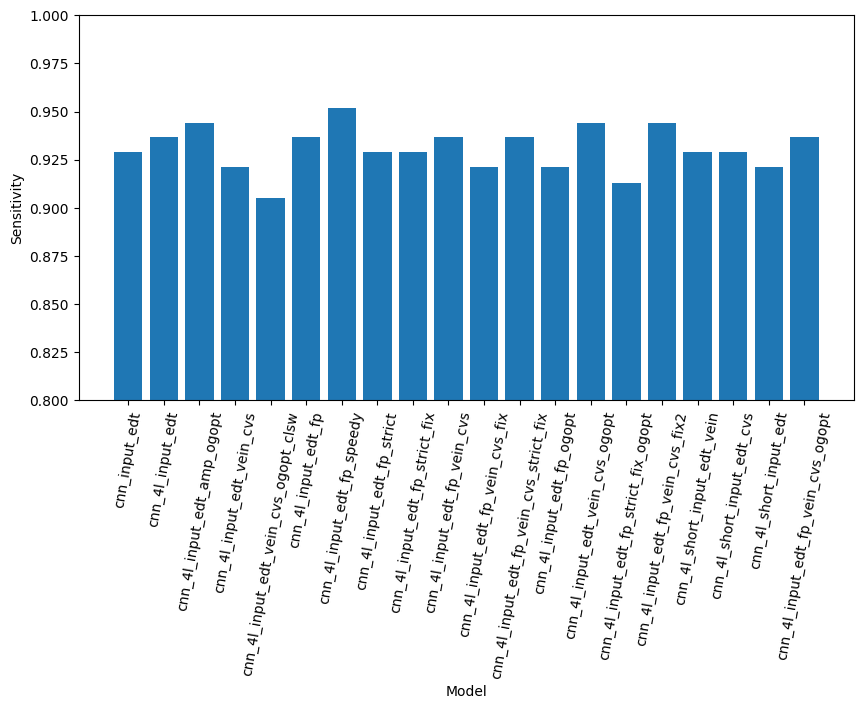

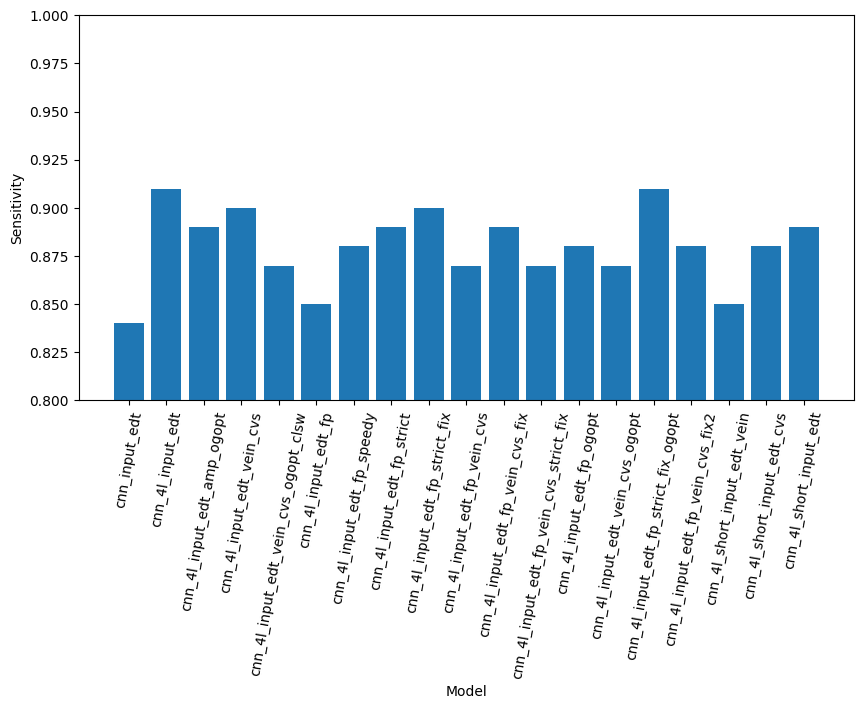

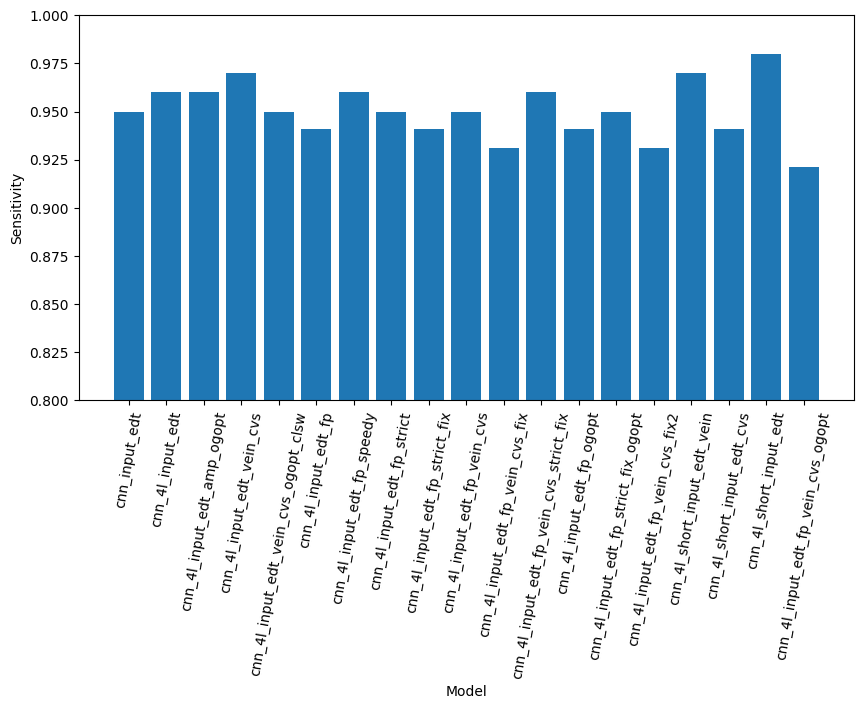

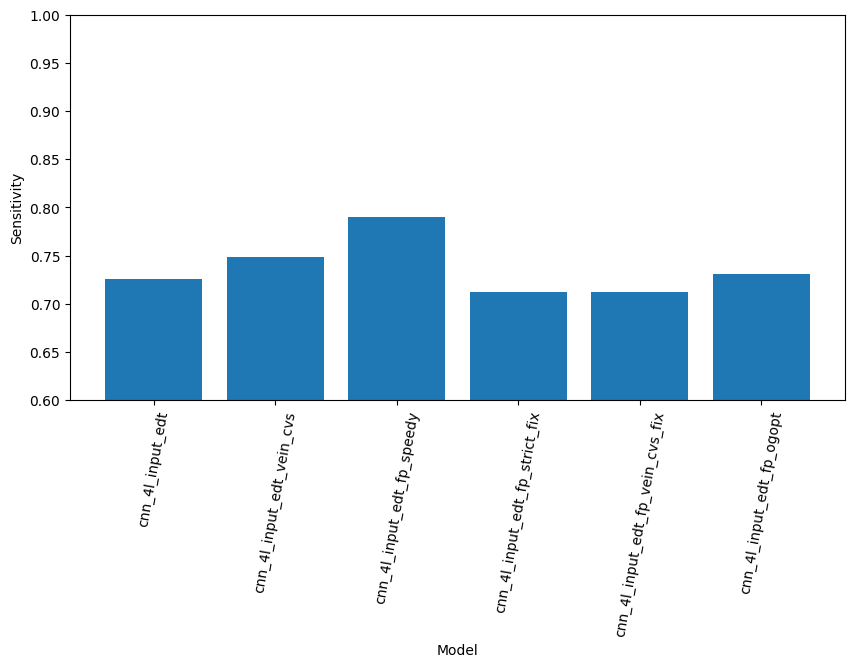

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
from pathlib import Path

path_results = "../../results"

datasets = ["internal_test", "cmha", "external", "hospital140"]
dataset = "internal_test"
for dataset in datasets:
    models = [
        "cnn_input_edt",
        "cnn_4l",
        "cnn_4l_input_edt",
        #"cnn_4l_input_edt_cvs",
        #"cnn_4l_nd_input_edt",
        #"cnn_4l_nd_input_edt_cvs",
        
        #"cnn_input_edt_cvs",
        "cnn_4l_input_edt_amp_ogopt",
        #"cnn_4l_input_edt_cvs_amp_ogopt",
        #"cnn_4l_nd_pe_edt",
        "cnn_4l_input_edt_vein_cvs",
        "cnn_4l_input_edt_vein_cvs_ogopt_clsw",
        "cnn_4l_input_edt_fp",
        "cnn_4l_input_edt_fp_speedy",
        "cnn_4l_input_edt_fp_strict",
        "cnn_4l_input_edt_fp_strict_fix",
        "cnn_4l_input_edt_fp_vein_cvs",
        "cnn_4l_input_edt_fp_vein_cvs_fix",
        
        "cnn_4l_input_edt_fp_vein_cvs_strict_fix",
        "cnn_4l_input_edt_fp_ogopt",
        "cnn_4l_input_edt_vein_cvs_ogopt",
        "cnn_4l_input_edt_fp_strict_fix_ogopt",
        "cnn_4l_input_edt_fp_vein_cvs_fix2",

        "cnn_4l_short_input_edt_vein",
        "cnn_4l_short_input_edt_cvs",
        "cnn_4l_short_input_edt",
        "cnn_4l_input_edt_fp_vein_cvs_ogopt"

    ]

    iou_thr = 0.3
    fp_thr = "0.5"
    list_sensitivity = []
    for model in models:

        path_results_model = Path(f"{path_results}/{dataset}/{model}/")

        results_model = list(path_results_model.glob("*"))


        results_model = [
            result for result in results_model if f"iou{iou_thr}" in str(result)
        ]
        results_model = sorted(results_model)
        for result in results_model:
            chpkt = result.name.split("_")[-1]
            df = pd.read_csv(result / "froc.csv")
            sensitivity = df[f"Se@FPpI={fp_thr}"].values[0]
            list_sensitivity.append([model, chpkt, sensitivity])


    cols = ["Model", "Checkpoint", f"Sensitivity@FPpI={fp_thr}"]

    df_sensitivity = pd.DataFrame(list_sensitivity, columns=cols)
    df_sensitivity = df_sensitivity.sort_values(by=["Model", "Checkpoint"])

    df_sensitivity = df_sensitivity.reset_index(drop=True)

    df_avg = (
        df_sensitivity[["Model", f"Sensitivity@FPpI={fp_thr}"]]
        .groupby("Model")
        .max()
        .reset_index()
    )

    # order models by the order in the 'models' list

    df_avg["Model"] = pd.Categorical(df_avg["Model"], categories=models, ordered=True)
    df_avg = df_avg.sort_values(by=["Model"])


    fig_avg = plt.figure(figsize=(10, 5))
    ax_avg = fig_avg.add_subplot(111)
    # plot bar
    plt.bar(df_avg["Model"], df_avg[f"Sensitivity@FPpI={fp_thr}"])
    plt.xticks(rotation=80)
    plt.xlabel("Model")
    plt.ylabel("Sensitivity")
    # set y range
    if dataset != "hospital140":
        plt.ylim(0.8, 1)
    else:
        plt.ylim(0.6, 1)

In [27]:
# fig = plt.figure(figsize=(10, 5))
# ax = fig.add_subplot(111)
# for model in models:
#     df_model = df_sensitivity[df_sensitivity["Model"] == model]
#     plt.plot(
#         df_model["Checkpoint"],
#         df_model[f"Sensitivity@FPpI={fp_thr}"],
#         marker="o",
#         label=model,
#     )
# plt.xticks(rotation=45)
# plt.xlabel("Checkpoint")
# plt.ylabel("Sensitivity")
# plt.title(f"Sensitivity vs Checkpoint for {dataset} dataset")
# plt.legend()

(0.8, 1.0)

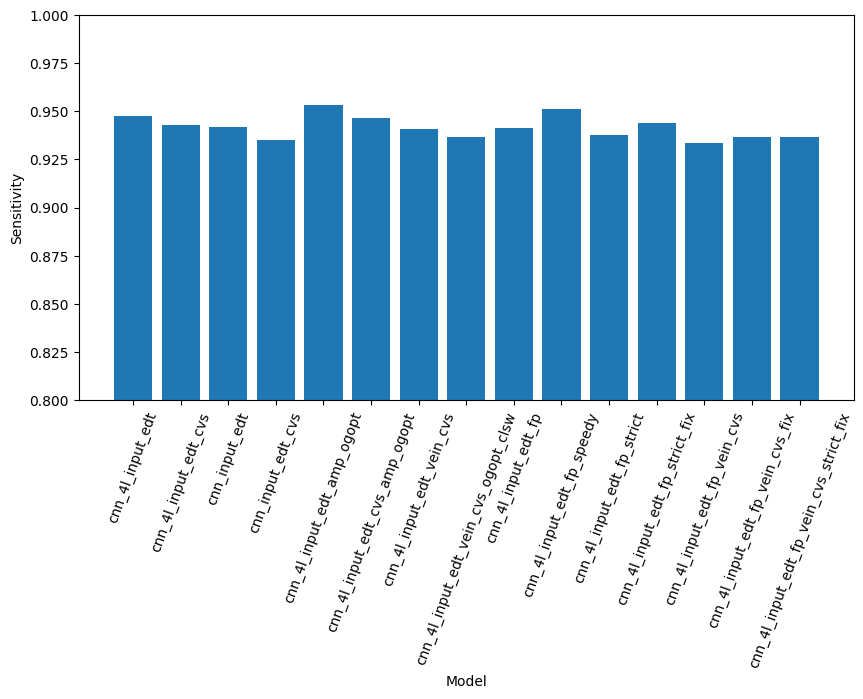

In [ ]:
# avg by model



In [ ]:
# avg by model

df_avg = (
    df_sensitivity[["Model", f"Sensitivity@FPpI={fp_thr}"]]
    .groupby("Model")
    .mean()
    .reset_index()
)
df_avg = df_avg.sort_values(by=["Model"])
fig_avg = plt.figure(figsize=(10, 5))

ax_avg = fig_avg.add_subplot(111)
# plot bar
plt.bar(df_avg["Model"], df_avg[f"Sensitivity@FPpI={fp_thr}"])
plt.xticks(rotation=45)
plt.xlabel("Model")
plt.ylabel("Sensitivity")
plt.title(f"Sensitivity vs Model for {dataset} dataset")
# set y range
plt.ylim(0.8, 1)